# Baseline pipeline test (constant predictor)

Goal: validate the train/val harness itself (dataset loading, CV split usage, metric,
eval loop) before building any real model. The "model" here predicts the training set's
mean target for every input, regardless of the actual thermal/SEM data — no learning,
no gradient descent. If this harness reports sane numbers, the plumbing works and a real
model is a drop-in replacement for `ConstantBaseline`.

Per `.CLAUDE.md` §3, Track 21 is the fixed held-out test set and is not touched here —
only tracks 8/10/14 (the dev tracks) are used, via Task 3's `loto_cv_splits`.

In [ ]:
import sys
import pickle
from pathlib import Path

# Auto-detect repo root: search upward from cwd for pyproject.toml -- robust to
# whatever directory Jupyter was launched from (local VS Code, remote Linux server, etc.)
def _find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    return p  # fallback: no marker found, use cwd as-is

REPO = _find_repo_root()
sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from preprocessing import loto_cv_splits, HELD_OUT_TEST_TRACK

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('using device:', device)

DATASETS_DIR = REPO / 'processed_data' / 'datasets'
run_dir = sorted(DATASETS_DIR.iterdir())[-1]
print('using processed data run:', run_dir.name)
print('held-out test track (not used below):', HELD_OUT_TEST_TRACK)

using processed data run: 20260715_145326
held-out test track (not used below): 21


## The metric

Single shared implementation, per `.CLAUDE.md` §3 ("metric has a single
implementation — not copied"). Mean absolute error in mm on `width_mean_mm`, the
primary Task-1 target.

In [ ]:
TARGET_KEY = 'width_mean_mm'

def mae_mm(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.mean(np.abs(y_true - y_pred)))

## The Dataset

Wraps one or more tracks' `track_<id>_samples.pkl` (Task 5 output). Filters to
`valid=True` samples only — the NaN-fraction gate from Task 1 already decided which
windows are trustworthy; we don't silently include invalid ones. Returns the full
thermal window tensor even though the baseline model ignores it, so a real model is a
drop-in swap later without touching this class.

In [ ]:
class TrackSampleDataset(Dataset):
    def __init__(self, run_dir, track_ids, target_key=TARGET_KEY):
        self.rows = []
        for track_id in track_ids:
            with open(Path(run_dir) / f'track_{track_id}_samples.pkl', 'rb') as f:
                track_rows = pickle.load(f)
            self.rows.extend(r for r in track_rows if r['valid'])
        self.target_key = target_key

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        thermal = torch.from_numpy(row['thermal_window'].copy())
        target = torch.tensor(row[self.target_key], dtype=torch.float32)
        return thermal, target

    def targets(self):
        return np.array([r[self.target_key] for r in self.rows], dtype=np.float64)

## The baseline "model"

Predicts a single learned constant (the training-set target mean) for every sample.
Fit via closed form, not backprop — there's nothing to learn, this is purely a plumbing
test. `forward` still takes the thermal tensor as input (and ignores it), matching the
interface a real model will need.

In [ ]:
class ConstantBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.value = nn.Parameter(torch.zeros(1), requires_grad=False)

    def fit(self, train_targets):
        self.value.data = torch.tensor([float(np.mean(train_targets))], device=self.value.device)

    def forward(self, x):
        return self.value.expand(x.shape[0])

## Run all 3 CV folds

For each fold: build train/val datasets, fit the baseline on train targets only (never
val — matches the "scaler fit on train only" invariant, same principle applies to any
fitted statistic), run both through a real `DataLoader` (so batching/collation of the
`(11,400,400)` thermal tensors is actually exercised, not skipped), and report MAE.

In [ ]:
results = []
for train_tracks, val_track in loto_cv_splits():
    train_ds = TrackSampleDataset(run_dir, train_tracks)
    val_ds = TrackSampleDataset(run_dir, [val_track])

    model = ConstantBaseline().to(device)
    model.fit(train_ds.targets())

    # pin_memory + worker processes materially help on a CUDA machine; no-ops on MPS/CPU.
    dataloader_kwargs = dict(pin_memory=True, num_workers=4) if device.type == 'cuda' else dict()

    def evaluate(ds):
        loader = DataLoader(ds, batch_size=16, shuffle=False, **dataloader_kwargs)
        all_true, all_pred = [], []
        with torch.no_grad():
            for thermal, target in loader:
                thermal = thermal.to(device)
                pred = model(thermal)
                all_true.append(target.numpy())
                all_pred.append(pred.cpu().numpy())
        return mae_mm(np.concatenate(all_true), np.concatenate(all_pred))

    train_mae = evaluate(train_ds)
    val_mae = evaluate(val_ds)
    results.append(dict(train_tracks=train_tracks, val_track=val_track,
                         n_train=len(train_ds), n_val=len(val_ds),
                         baseline_value=model.value.item(),
                         train_mae=train_mae, val_mae=val_mae))
    print(f'train={train_tracks} val={val_track}: n_train={len(train_ds)} n_val={len(val_ds)} '
          f'baseline={model.value.item():.4f}mm  train_MAE={train_mae:.4f}mm  val_MAE={val_mae:.4f}mm')

train=(10, 14) val=8: n_train=713 n_val=375 baseline=0.5243mm  train_MAE=0.2015mm  val_MAE=0.2376mm
train=(8, 14) val=10: n_train=738 n_val=350 baseline=0.5121mm  train_MAE=0.2417mm  val_MAE=0.1501mm
train=(8, 10) val=14: n_train=725 n_val=363 baseline=0.4647mm  train_MAE=0.1855mm  val_MAE=0.2572mm


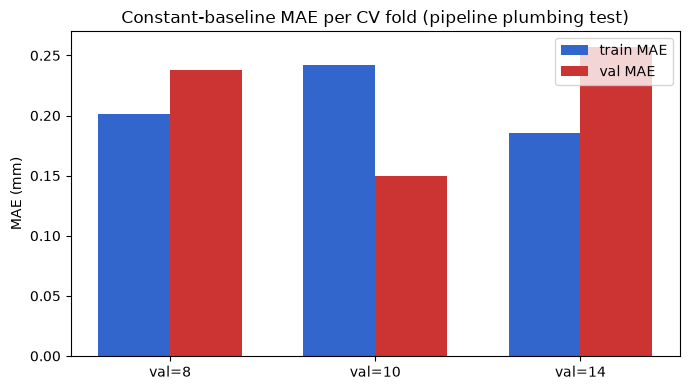

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results))
width = 0.35
ax.bar(x - width/2, [r['train_mae'] for r in results], width, label='train MAE', color='#3366cc')
ax.bar(x + width/2, [r['val_mae'] for r in results], width, label='val MAE', color='#cc3333')
ax.set_xticks(x)
ax.set_xticklabels([f"val={r['val_track']}" for r in results])
ax.set_ylabel('MAE (mm)')
ax.set_title('Constant-baseline MAE per CV fold (pipeline plumbing test)')
ax.legend()
plt.tight_layout()
plt.show()

## What this does and doesn't tell us

**What it validates:** the dataset loads real pickled samples correctly, the CV split
tracks route to the right train/val sets, the `DataLoader` batches the `(11,400,400)`
thermal tensors without shape/memory errors, and `mae_mm` computes sensibly — the whole
harness runs end to end without crashing or producing NaN/garbage numbers.

**What it doesn't tell us:** anything about whether a real model can learn — by
construction, `val_mae` here is just "how far is the val track's average width from the
train tracks' average width," which is really a measure of how different the tracks are
from each other, not a measure of predictive skill. A real model should beat this
baseline; if it can't, that's the bar it needs to clear.

**Next step**, once this is confirmed sane: swap `ConstantBaseline` for a real minimal
model (e.g. a small CNN on the thermal window) that actually trains via gradient
descent — everything else in this harness (dataset, CV loop, metric) stays the same.